# Extracting interaction profiles

Interaction profiles (surface point cloud, ESP on a surface point cloud, and pharmacophores) can be generated for any arbituary conformer.

In [1]:
import open3d # open3d can occasionally cause issues during imports; importing it first can help alleviate that
from rdkit import Chem
from shepherd_score.conformer_generation import embed_conformer_from_smiles, charges_from_single_point_conformer_with_xtb
from shepherd_score.extract_profiles import get_atomic_vdw_radii, get_molecular_surface
from shepherd_score.extract_profiles import get_pharmacophores, get_electrostatic_potential, get_pharmacophores_dict

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Get a conformer with RDKit embedding and MMFF94 optimization then obtain charges from xTB.

In [2]:
ref_mol = embed_conformer_from_smiles('CC(Cc1ccc(cc1)C(C(=O)O)C)C', MMFF_optimize=True)
partial_charges = charges_from_single_point_conformer_with_xtb(ref_mol)

### Extract surface
The vdW radii and the positions of each atom is used to generate a surface. Here we sample 200 points on the solvent accessible surface with a probe radius of 1.2 A. Note that the sampling is stochastic.

In [3]:
radii = get_atomic_vdw_radii(ref_mol)
surface = get_molecular_surface(ref_mol.GetConformer().GetPositions(), radii, num_points=200, probe_radius=1.2)
surface.shape

(200, 3)

### Extract electrostatic potential (ESP)
The ESP at each surface point is be computed from the partial charges.

In [4]:
esp = get_electrostatic_potential(ref_mol, partial_charges, surface)
esp.shape

(200,)

### Extract pharmacophores

Pharmacophores are extracted using pre-defined SMARTS patterns given an RDKit Mol object. Using `get_pharmacophores` returns a tuple of NumPy arrays corresponding to the type, position, and unit vector of each pharmacophore: `(pharm_types, pharm_positions, pharm_vectors)`. `get_pharmacophores_dict` is a helper function that provides an easy to interpret version. Non-directional pharmacophores (e.g., hydrophobe) have vectors set to the zero vector.

In [5]:
get_pharmacophores_dict(ref_mol, multi_vector=False)

{'Aromatic': {'P': [(0.5648232924460855,
    0.0031643820747157547,
    0.35511810481624356)],
  'V': [(-0.2945556771928463, -0.4073360299367432, -0.8644734303313414)]},
 'Donor': {'P': [(4.509339913910732, 1.7952242305121755, -0.2268082367772607)],
  'V': [(0.5682569410292456, 0.4760407514118759, 0.6711700618824569)]},
 'Acceptor': {'P': [(4.775169737464007,
    0.34224591284067285,
    1.4348617088438365),
   (4.509339913910732, 1.7952242305121755, -0.2268082367772607)],
  'V': [(0.4020890057795158, -0.20683058498962514, 0.89193359648804),
   (-0.2819415443678374, 0.40915215126549526, -0.8678153505638719)]},
 'Hydrophobe': {'P': [(0.5648232924460854,
    0.0031643820747157734,
    0.35511810481624356),
   (3.573958154566982, -0.18654880497956533, -1.9596704739077149),
   (-3.6964382917774663, -0.40704674155076476, 0.07551702677506615)],
  'V': [(0, 0, 0), (0, 0, 0), (0, 0, 0)]}}

In [6]:
pharm_types, pharm_pos, pharm_vecs = get_pharmacophores(ref_mol, multi_vector=False)

In [7]:
pharm_types.shape, pharm_pos.shape, pharm_vecs.shape

((7,), (7, 3), (7, 3))

The pharmacophore types are ordered (with 0 indexing) of the following list.

In [8]:
from shepherd_score.score.constants import P_TYPES
P_TYPES

('Acceptor',
 'Donor',
 'Aromatic',
 'Hydrophobe',
 'Halogen',
 'Cation',
 'Anion',
 'ZnBinder')

## Abstracted objects

We introduce the `Molecule` object that facilitates automatic generation of interaction profiles. It holds these profiles as attributes, alongside the RDKit `Mol` object. 

In [9]:
from shepherd_score.container import Molecule

The same procedure is used as above to extract each interaction profile. Note that if xTB partial charges were not supplied to `Molecule`, the object would compute ESP using MMFF94 partial charges which are not recommended.

In [10]:
molec = Molecule(ref_mol, num_surf_points=200, probe_radius=1.2,
                 partial_charges=partial_charges, pharm_multi_vector=False)

In [11]:
molec.surf_pos.shape, molec.surf_esp.shape

((200, 3), (200,))

In [12]:
molec.pharm_types.shape, molec.pharm_ancs.shape, molec.pharm_vecs.shape

((7,), (7, 3), (7, 3))

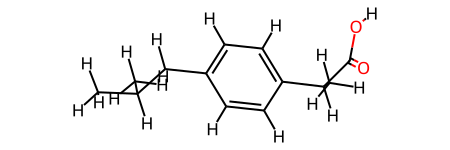

In [13]:
molec.mol # rdkit mol object